In [1]:
from torch.utils.data import Dataset, DataLoader
import torch
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans, HDBSCAN
# GaussianMixture
from sklearn.mixture import GaussianMixture

import matplotlib.pyplot as plt
import yfinance as yf
import seaborn as sns
# import
from hmmlearn.hmm import GaussianHMM
import pickle

In [2]:
device ="mps"

In [3]:
with open('../../data/complete_features.pkl', 'rb') as f:
    all_data = pickle.load(f)

In [4]:
data = all_data["scaled_featured"].copy()

In [5]:
data

,rolling_sharpe_20,rolling_max_dd_60,realized_vol_20,vol_slope_20,autocorr_20,rel_spx_20,usdinr_vol_20,rel_gold_20,vix_level_20,vix_slope_20,trend_strength_200,sector_dispersion_ratio_20
Date,,,,,,,,,,,,
2008-07-07,-1.220376,-1.882225,2.081321,-0.864592,-1.135796,-0.628471,-0.569023,-2.119483,1.416877,0.823997,-2.165333,-0.568676
2008-07-08,-1.211754,-1.882225,2.077736,-0.022097,-1.117078,-1.046961,-0.542321,-2.455523,1.450259,0.981827,-2.206775,-0.513460
2008-07-09,-0.957426,-1.882225,2.289506,1.636228,-1.218247,-0.338846,-0.561373,-1.988903,1.476862,0.785786,-1.960992,-0.565134
2008-07-10,-0.975703,-1.882225,2.287995,-0.006124,-1.013921,-0.474801,-0.596656,-2.401313,1.493754,0.505013,-1.940271,-0.562557
2008-07-11,-1.136144,-1.882225,2.391761,0.804554,-1.050675,-0.396400,-0.475448,-2.987661,1.507027,0.400347,-2.078101,-0.510752
...,...,...,...,...,...,...,...,...,...,...,...,...
2025-09-15,0.375855,0.654743,-0.795604,0.021503,0.541634,-0.126723,-0.727148,-1.189892,-0.988672,-0.309058,0.314003,0.507783
2025-09-16,0.280399,0.654743,-0.833663,-0.287568,0.045456,-0.238463,-0.708679,-1.276291,-1.000565,-0.327333,0.453848,0.513354
2025-09-17,0.260114,0.654743,-0.836851,-0.019044,0.154682,-0.363408,-0.703390,-1.335486,-1.009414,-0.239281,0.522324,0.511624


In [6]:
data.head()

,rolling_sharpe_20,rolling_max_dd_60,realized_vol_20,vol_slope_20,autocorr_20,rel_spx_20,usdinr_vol_20,rel_gold_20,vix_level_20,vix_slope_20,trend_strength_200,sector_dispersion_ratio_20
Date,,,,,,,,,,,,
2008-07-07,-1.220376,-1.882225,2.081321,-0.864592,-1.135796,-0.628471,-0.569023,-2.119483,1.416877,0.823997,-2.165333,-0.568676
2008-07-08,-1.211754,-1.882225,2.077736,-0.022097,-1.117078,-1.046961,-0.542321,-2.455523,1.450259,0.981827,-2.206775,-0.513460
2008-07-09,-0.957426,-1.882225,2.289506,1.636228,-1.218247,-0.338846,-0.561373,-1.988903,1.476862,0.785786,-1.960992,-0.565134
2008-07-10,-0.975703,-1.882225,2.287995,-0.006124,-1.013921,-0.474801,-0.596656,-2.401313,1.493754,0.505013,-1.940271,-0.562557
2008-07-11,-1.136144,-1.882225,2.391761,0.804554,-1.050675,-0.396400,-0.475448,-2.987661,1.507027,0.400347,-2.078101,-0.510752


In [7]:
data.tail()

,rolling_sharpe_20,rolling_max_dd_60,realized_vol_20,vol_slope_20,autocorr_20,rel_spx_20,usdinr_vol_20,rel_gold_20,vix_level_20,vix_slope_20,trend_strength_200,sector_dispersion_ratio_20
Date,,,,,,,,,,,,
2025-09-15,0.375855,0.654743,-0.795604,0.021503,0.541634,-0.126723,-0.727148,-1.189892,-0.988672,-0.309058,0.314003,0.507783
2025-09-16,0.280399,0.654743,-0.833663,-0.287568,0.045456,-0.238463,-0.708679,-1.276291,-1.000565,-0.327333,0.453848,0.513354
2025-09-17,0.260114,0.654743,-0.836851,-0.019044,0.154682,-0.363408,-0.703390,-1.335486,-1.009414,-0.239281,0.522324,0.511624
2025-09-18,0.293060,0.654743,-0.832619,0.038097,0.230366,-0.508229,-0.737254,-1.044970,-1.020331,-0.299090,0.591810,0.309460
2025-09-19,0.080198,0.654743,-0.823297,0.077298,0.164701,-0.717435,-0.742174,-1.146226,-1.028834,-0.229313,0.500421,0.283359


In [8]:
data

,rolling_sharpe_20,rolling_max_dd_60,realized_vol_20,vol_slope_20,autocorr_20,rel_spx_20,usdinr_vol_20,rel_gold_20,vix_level_20,vix_slope_20,trend_strength_200,sector_dispersion_ratio_20
Date,,,,,,,,,,,,
2008-07-07,-1.220376,-1.882225,2.081321,-0.864592,-1.135796,-0.628471,-0.569023,-2.119483,1.416877,0.823997,-2.165333,-0.568676
2008-07-08,-1.211754,-1.882225,2.077736,-0.022097,-1.117078,-1.046961,-0.542321,-2.455523,1.450259,0.981827,-2.206775,-0.513460
2008-07-09,-0.957426,-1.882225,2.289506,1.636228,-1.218247,-0.338846,-0.561373,-1.988903,1.476862,0.785786,-1.960992,-0.565134
2008-07-10,-0.975703,-1.882225,2.287995,-0.006124,-1.013921,-0.474801,-0.596656,-2.401313,1.493754,0.505013,-1.940271,-0.562557
2008-07-11,-1.136144,-1.882225,2.391761,0.804554,-1.050675,-0.396400,-0.475448,-2.987661,1.507027,0.400347,-2.078101,-0.510752
...,...,...,...,...,...,...,...,...,...,...,...,...
2025-09-15,0.375855,0.654743,-0.795604,0.021503,0.541634,-0.126723,-0.727148,-1.189892,-0.988672,-0.309058,0.314003,0.507783
2025-09-16,0.280399,0.654743,-0.833663,-0.287568,0.045456,-0.238463,-0.708679,-1.276291,-1.000565,-0.327333,0.453848,0.513354
2025-09-17,0.260114,0.654743,-0.836851,-0.019044,0.154682,-0.363408,-0.703390,-1.335486,-1.009414,-0.239281,0.522324,0.511624


In [9]:
close = all_data["Close"].copy()
close

Date
2008-07-07     4030.000000
2008-07-08     3988.550049
2008-07-09     4157.100098
2008-07-10     4162.200195
2008-07-11     4049.000000
                  ...     
2025-09-15    25069.199219
2025-09-16    25239.099609
2025-09-17    25330.250000
2025-09-18    25423.599609
2025-09-19    25327.050781
Name: Close, Length: 4219, dtype: float64

In [10]:
data.shape

(4219, 12)

In [11]:
class TimeSeriesWindowDataset(Dataset):
    def __init__(self, data, window_size=60):
        """
        data: numpy array [T, D]
        """
        self.data = torch.tensor(data, dtype=torch.float32)
        self.window_size = window_size

    def __len__(self):
        return len(self.data) - self.window_size + 1

    def __getitem__(self, idx):
        x = self.data[idx : idx + self.window_size]
        return x

window_size = 60
val_size = 0

train_size = int(len(data) * (1 - val_size))
train_data = data.iloc[:train_size]
val_data = data.iloc[train_size:]

train_dataset = TimeSeriesWindowDataset(train_data.values, window_size)
val_dataset = TimeSeriesWindowDataset(val_data.values, window_size)
combined_dataset = TimeSeriesWindowDataset(data.values, window_size)

batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
combined_loader = DataLoader(combined_dataset, batch_size=batch_size, shuffle=False)



In [12]:
len(combined_dataset)

4160

In [13]:
for batch in train_loader:
    print(batch.shape)  # Should print torch.Size([32, 60, D])
    break

torch.Size([32, 60, 12])


In [14]:
import torch.nn as nn
import torch.nn.functional as F

class TS2VecModel(nn.Module):
    def __init__(self, input_dim, hidden_dim=64, num_layers=5):
        super(TS2VecModel, self).__init__()
        layers = []
        for i in range(num_layers):
            dilation = 2 ** i
            layers.append(nn.Conv1d(input_dim if i == 0 else hidden_dim, hidden_dim, kernel_size=3, padding=dilation, dilation=dilation))
            layers.append(nn.ReLU())
        self.network = nn.Sequential(*layers)

    def forward(self, x):
        # x: [B, T, D]
        x = x.permute(0, 2, 1)  # [B, D, T]
        x = self.network(x)     # [B, H, T]
        x = x.permute(0, 2, 1)  # [B, T, H]
        # normalize
        x = F.normalize(x, p=2, dim=-1)
        return x

In [15]:
data.shape

(4219, 12)

In [16]:
model = TS2VecModel(input_dim=data.shape[1], hidden_dim=64, num_layers=5).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [17]:
model

TS2VecModel(
  (network): Sequential(
    (0): Conv1d(12, 64, kernel_size=(3,), stride=(1,), padding=(1,))
    (1): ReLU()
    (2): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(2,), dilation=(2,))
    (3): ReLU()
    (4): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(4,), dilation=(4,))
    (5): ReLU()
    (6): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(8,), dilation=(8,))
    (7): ReLU()
    (8): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(16,), dilation=(16,))
    (9): ReLU()
  )
)

In [59]:
def time_mask(x, mask_ratio=0.2):
    B, T, D = x.shape
    mask_len = int(T * mask_ratio)
    start = np.random.randint(0, T - mask_len)
    x = x.clone()
    x[:, start:start+mask_len, :] = 0
    return x

def temporal_negative_mask(B, T, exclusion_radius, device):
    """
    Returns mask of shape [B*T, B*T]
    True = allowed negative
    False = masked out
    """
    BT = B * T
    mask = torch.ones(BT, BT, device=device, dtype=torch.bool)

    for b in range(B):
        for t in range(T):
            idx = b*T + t
            start = max(0, t - exclusion_radius)
            end   = min(T, t + exclusion_radius + 1)
            for tt in range(start, end):
                mask[idx, b*T + tt] = False

    return mask



def jitter(x, sigma=0.02):
    return x + sigma * torch.randn_like(x)


# def temporal_pooling(z):
#     """
#     z: [B, T, C]
#     returns: [B, T//2, C]
#     """
#     if z.size(1) % 2 == 1:
#         z = z[:, :-1, :]
#     z = z.reshape(z.size(0), z.size(1)//2, 2, z.size(2))
#     return z.max(dim=2).values

def temporal_pooling(z):
    if z.size(1) % 2 == 1:
        z = z[:, :-1]
    return z.reshape(z.size(0), z.size(1)//2, 2, z.size(2)).mean(dim=2)

def instance_contrastive_loss(z1, z2, temperature=0.1):
    """
    z1, z2: [B, T, C]
    """
    B, T, C = z1.shape

    z1 = z1.reshape(B*T, C)
    z2 = z2.reshape(B*T, C)

    sim = torch.matmul(z1, z2.T) / temperature  # [BT, BT]
    labels = torch.arange(B*T, device=device)
    
    return F.cross_entropy(sim, labels)
    
def masked_instance_contrastive_loss(
    z1, z2, exclusion_radius=5, temperature=0.1
):
    B, T, C = z1.shape
    z1 = z1.reshape(B*T, C)
    z2 = z2.reshape(B*T, C)

    sim = torch.matmul(z1, z2.T) / temperature
    mask = temporal_negative_mask(B, T, exclusion_radius, z1.device)

    # mask invalid negatives
    sim = sim.masked_fill(~mask, -1e9)

    labels = torch.arange(B*T, device=z1.device)
    return F.cross_entropy(sim, labels)

def hierarchical_contrastive_loss(z1, z2, temperature=0.1, min_time=2):
    """
    z1, z2: [B, T, C]
    """
    total_loss = 0.0
    depth = 0

    while z1.size(1) >= min_time:
        loss = instance_contrastive_loss(z1, z2, temperature)
        total_loss += loss

        # downsample
        z1 = temporal_pooling(z1)
        z2 = temporal_pooling(z2)
        depth += 1

    return total_loss / depth

def ts2vec_contrastive_loss(
    z1, z2,
    temperature=0.1,
    exclusion_radius=5
):
    """
    z1, z2: [B, T, C]
    """
    B, T, C = z1.shape
    loss = 0.0
    count = 0

    for t in range(T):
        pos_sim = F.cosine_similarity(
            z1[:, t], z2[:, t], dim=-1
        ) / temperature  # [B]

        # negatives: all other timestamps except nearby
        neg_sims = []
        for tt in range(T):
            if abs(tt - t) > exclusion_radius:
                neg = F.cosine_similarity(
                    z1[:, t].unsqueeze(1),
                    z2[:, tt].unsqueeze(0),
                    dim=-1
                ) / temperature
                neg_sims.append(neg)

        if len(neg_sims) == 0:
            continue

        neg_sims = torch.cat(neg_sims, dim=1)

        logits = torch.cat(
            [pos_sim.unsqueeze(1), neg_sims], dim=1
        )

        labels = torch.zeros(B, dtype=torch.long, device=z1.device)
        loss += F.cross_entropy(logits, labels)
        count += 1

    return loss / count

def ts2vec_contrastive_loss_vectorized(
    z1, z2,
    temperature=0.1,
    base_exclusion_radius=5
):
    """
    z1, z2: [B, T, C]
    """
    B, T, C = z1.shape
    device = z1.device

    # flatten (instance, time)
    z1_flat = z1.reshape(B*T, C)
    z2_flat = z2.reshape(B*T, C)

    # cosine similarity == dot product because embeddings are normalized
    sim = torch.matmul(z1_flat, z2_flat.T) / temperature   # [BT, BT]

    # ----- temporal negative mask -----
    exclusion_radius = min(base_exclusion_radius, (T - 1) // 2)

    if exclusion_radius == 0:
        return torch.tensor(0.0, device=device)

    # time index per row
    time_idx = torch.arange(T, device=device).repeat(B)     # [BT]

    # batch index per row
    batch_idx = torch.arange(B, device=device).repeat_interleave(T)

    # same batch & temporally close → mask out
    temporal_dist = torch.abs(time_idx[:, None] - time_idx[None, :])
    same_batch = batch_idx[:, None] == batch_idx[None, :]

    invalid_negatives = same_batch & (temporal_dist <= exclusion_radius)

    # allow diagonal (positive pairs)
    diag = torch.eye(B*T, device=device, dtype=torch.bool)
    invalid_negatives = invalid_negatives & (~diag)

    # mask invalid negatives
    sim = sim.masked_fill(invalid_negatives, -1e9)

    # positives are diagonal
    labels = torch.arange(B*T, device=device)

    return F.cross_entropy(sim, labels)


def hierarchical_ts2vec_loss(
    z1, z2,
    temperature=0.1,
    exclusion_radius=5,
    min_time=2
):
    total_loss = 0.0
    depth = 0

    while z1.size(1) >= min_time:
        total_loss += ts2vec_contrastive_loss_vectorized(
            z1, z2,
            temperature,
            exclusion_radius
        )

        z1 = temporal_pooling(z1)
        z2 = temporal_pooling(z2)
        depth += 1

    return total_loss / depth

def hierarchical_ts2vec_loss_v2(
    z1, z2,
    temperature=0.1,
    exclusion_radius=5,
    min_time=2
):
    total_loss = 0.0
    depth = 0

    while z1.size(1) >= min_time:
        T = z1.size(1)

        if T > 2 * exclusion_radius + 1:
            total_loss += ts2vec_contrastive_loss_vectorized(
                z1, z2,
                temperature,
                exclusion_radius
            )
            depth += 1

        z1 = temporal_pooling(z1)
        z2 = temporal_pooling(z2)

    return total_loss / max(depth, 1)



def embedding_variance(z):
    # z: [B, T, C]
    return z.var(dim=0).mean().item() # mean over T and C


In [60]:
%%time
# embedding_variance_1 = []
# embedding_variance_2 = []
for epoch in range(20):
    total_loss = 0
    model.train()
    for x in train_loader:
        x=x.to(device)
        x1 = jitter(time_mask(x))
        x2 = jitter(time_mask(x))
        z1 = model(x1)
        z2 = model(x2)

        # embedding_variance_1.append(embedding_variance(z1))
        # embedding_variance_2.append(embedding_variance(z2))

        loss = hierarchical_ts2vec_loss_v2(z1, z2)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        # print(f"Batch Loss: {loss.item():.4f}")
    # model.eval()
    # with torch.no_grad():
    #     val_loss = 0
    #     for x in val_loader:
    #         x = x.to(device)
    #         x1 = jitter(time_mask(x))
    #         x2 = jitter(time_mask(x))
    #         z1 = model(x1)
    #         z2 = model(x2)
    #         val_loss += hierarchical_ts2vec_loss_v2(z1, z2).item()

    # val_loss /= len(val_loader)

    print(f"Epoch {epoch}, Loss {total_loss / len(train_loader):.4f}")

Epoch 0, Loss 1.9755
Epoch 1, Loss 1.0924
Epoch 2, Loss 0.8854
Epoch 3, Loss 0.8285
Epoch 4, Loss 0.7542
Epoch 5, Loss 0.6948
Epoch 6, Loss 0.6836
Epoch 7, Loss 0.6382
Epoch 8, Loss 0.6298
Epoch 9, Loss 0.6110
Epoch 10, Loss 0.6087
Epoch 11, Loss 0.5917
Epoch 12, Loss 0.5814
Epoch 13, Loss 0.5623
Epoch 14, Loss 0.5722
Epoch 15, Loss 0.5593
Epoch 16, Loss 0.5493
Epoch 17, Loss 0.5501
Epoch 18, Loss 0.5388
Epoch 19, Loss 0.5327
CPU times: user 19.2 s, sys: 4.01 s, total: 23.2 s
Wall time: 20 s


In [ ]:
# save model
# torch.save(model.state_dict(), './../../models/ts2vec_nifty.pth')

In [18]:
# load model
model.load_state_dict(torch.load('../../models/ts2vec_nifty.pth'))

<All keys matched successfully>

In [48]:
with open('../../data/new_scaled_features.pkl', 'rb') as f:
    new_scaled_features = pickle.load(f)
new_df = new_scaled_features["scaled_features"]


In [57]:
new_scaled_features["Close"]

Date
2025-06-27    25637.800781
2025-06-30    25517.050781
2025-07-01    25541.800781
2025-07-02    25453.400391
2025-07-03    25405.300781
                  ...     
2026-02-13    25471.099609
2026-02-16    25682.750000
2026-02-17    25725.400391
2026-02-18    25819.349609
2026-02-19    25454.349609
Name: Close, Length: 162, dtype: float64

In [49]:
# model.eval()
# all_embeddings = []

# with torch.inference_mode():
#     for x in val_loader:
#         # print("x.shape", x.shape)
#         x = x.to(device)    
#         z = model(x)          # [B, T, C]
#         z_mean = z.mean(dim=1)  # [B, C]
#         all_embeddings.append(z_mean)

# embeddings = torch.cat(all_embeddings).cpu().numpy()

In [50]:
new_df.shape

(162, 12)

In [51]:
new_df

,rolling_sharpe_20,rolling_max_dd_60,realized_vol_20,vol_slope_20,autocorr_20,rel_spx_20,usdinr_vol_20,rel_gold_20,vix_level_20,vix_slope_20,trend_strength_200,sector_dispersion_ratio_20
Date,,,,,,,,,,,,
2025-06-27,0.798826,0.447462,-0.593711,0.009201,0.356613,-0.200888,-0.542173,0.544669,-0.628762,-0.596476,0.810645,-0.057347
2025-06-30,0.675988,0.447462,-0.582376,0.092789,0.115660,-0.301578,-0.531930,0.757795,-0.653870,-0.709449,0.701643,-0.100755
2025-07-01,0.981913,0.447462,-0.609857,-0.206111,0.231964,0.040351,-0.516026,0.603365,-0.677025,-0.652962,0.716140,-0.026861
2025-07-02,0.751418,0.447462,-0.608705,0.014383,0.236594,-0.217982,-0.565817,0.559314,-0.695986,-0.531682,0.636009,-0.000126
2025-07-03,0.526074,0.447462,-0.622690,-0.102189,0.137778,-0.693584,-0.583572,0.429694,-0.711442,-0.430338,0.595629,0.001498
...,...,...,...,...,...,...,...,...,...,...,...,...
2026-02-13,-0.479008,0.668348,-0.319403,0.578947,-0.187915,0.110005,0.076889,-1.308994,-0.812337,0.343861,-0.243405,0.225053
2026-02-16,-0.310087,0.668348,-0.290313,0.229518,-0.533300,0.318026,0.075401,-1.324313,-0.801075,0.342199,0.055013,0.135632
2026-02-17,-0.173470,0.668348,-0.296863,-0.044930,-0.746331,0.429565,0.057481,-0.837821,-0.796249,0.156126,0.110644,0.165542


In [52]:
# convert to tensor of shape [T[idx : idx+Window], D]
new_dataset = TimeSeriesWindowDataset(new_df.values, window_size)
new_loader = DataLoader(new_dataset, batch_size=1, shuffle=False)
new_embeddings = []
model.eval()
with torch.inference_mode():
    for x in new_loader:
        x = x.to(device)
        z = model(x)
        z_mean = z.mean(dim=1)
        # break
        new_embeddings.append(z_mean)
embeddings_ = torch.cat(new_embeddings).cpu().numpy()

In [53]:
embeddings_[0].shape

(64,)

2025-09-19 00:00:00

In [54]:
new_df = pd.DataFrame(embeddings_,
                      index=new_df.index[window_size-1:])
new_df

,0,1,2,3,4,5,6,7,8,9,...,54,55,56,57,58,59,60,61,62,63
Date,,,,,,,,,,,,,,,,,,,,,
2025-09-22,0.0,0.029748,0.059888,0.000647,0.0,0.058480,0.164221,0.033598,0.078885,0.025395,...,0.0,0.045337,0.000649,0.0,0.002006,0.000000,0.0,0.051232,0.084207,0.099354
2025-09-23,0.0,0.028364,0.061520,0.001627,0.0,0.061448,0.164996,0.034486,0.079725,0.029861,...,0.0,0.042712,0.000143,0.0,0.003235,0.000000,0.0,0.051494,0.077376,0.093327
2025-09-24,0.0,0.026550,0.061947,0.002922,0.0,0.062570,0.162276,0.034639,0.081293,0.034162,...,0.0,0.042411,0.000105,0.0,0.004253,0.000000,0.0,0.051101,0.068518,0.088259
2025-09-25,0.0,0.023837,0.061498,0.004292,0.0,0.060381,0.160451,0.035796,0.082584,0.038182,...,0.0,0.044660,0.000603,0.0,0.007293,0.000000,0.0,0.048084,0.059472,0.083237
2025-09-26,0.0,0.021092,0.058885,0.006007,0.0,0.058932,0.163815,0.036404,0.083164,0.041136,...,0.0,0.042865,0.002708,0.0,0.009461,0.000000,0.0,0.043547,0.056614,0.078620
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-02-13,0.0,0.154281,0.008402,0.044421,0.0,0.052127,0.069970,0.042097,0.008249,0.000567,...,0.0,0.016039,0.000000,0.0,0.108517,0.009591,0.0,0.029182,0.051806,0.000000
2026-02-16,0.0,0.158853,0.010573,0.043895,0.0,0.049044,0.068458,0.041026,0.008487,0.000000,...,0.0,0.015723,0.000000,0.0,0.111690,0.012029,0.0,0.030499,0.056426,0.000000
2026-02-17,0.0,0.162482,0.016346,0.044965,0.0,0.046490,0.067333,0.042729,0.009003,0.000000,...,0.0,0.016110,0.000000,0.0,0.113847,0.013575,0.0,0.031153,0.062543,0.000000


In [58]:
new_df["Close"]= new_scaled_features["Close"].iloc[window_size-1:]
new_df

,0,1,2,3,4,5,6,7,8,9,...,55,56,57,58,59,60,61,62,63,Close
Date,,,,,,,,,,,,,,,,,,,,,
2025-09-22,0.0,0.029748,0.059888,0.000647,0.0,0.058480,0.164221,0.033598,0.078885,0.025395,...,0.045337,0.000649,0.0,0.002006,0.000000,0.0,0.051232,0.084207,0.099354,25202.349609
2025-09-23,0.0,0.028364,0.061520,0.001627,0.0,0.061448,0.164996,0.034486,0.079725,0.029861,...,0.042712,0.000143,0.0,0.003235,0.000000,0.0,0.051494,0.077376,0.093327,25169.500000
2025-09-24,0.0,0.026550,0.061947,0.002922,0.0,0.062570,0.162276,0.034639,0.081293,0.034162,...,0.042411,0.000105,0.0,0.004253,0.000000,0.0,0.051101,0.068518,0.088259,25056.900391
2025-09-25,0.0,0.023837,0.061498,0.004292,0.0,0.060381,0.160451,0.035796,0.082584,0.038182,...,0.044660,0.000603,0.0,0.007293,0.000000,0.0,0.048084,0.059472,0.083237,24890.849609
2025-09-26,0.0,0.021092,0.058885,0.006007,0.0,0.058932,0.163815,0.036404,0.083164,0.041136,...,0.042865,0.002708,0.0,0.009461,0.000000,0.0,0.043547,0.056614,0.078620,24654.699219
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-02-13,0.0,0.154281,0.008402,0.044421,0.0,0.052127,0.069970,0.042097,0.008249,0.000567,...,0.016039,0.000000,0.0,0.108517,0.009591,0.0,0.029182,0.051806,0.000000,25471.099609
2026-02-16,0.0,0.158853,0.010573,0.043895,0.0,0.049044,0.068458,0.041026,0.008487,0.000000,...,0.015723,0.000000,0.0,0.111690,0.012029,0.0,0.030499,0.056426,0.000000,25682.750000
2026-02-17,0.0,0.162482,0.016346,0.044965,0.0,0.046490,0.067333,0.042729,0.009003,0.000000,...,0.016110,0.000000,0.0,0.113847,0.013575,0.0,0.031153,0.062543,0.000000,25725.400391


In [59]:
# save new_df
with open('../../data/infer_ts2vec_embeddings.pkl', 'wb') as f:
    pickle.dump(new_df, f)

In [ ]:
import os
import copy
import torch

onnx_path = os.path.abspath('./../../models/ts2vec_nifty.onnx')

model_cpu = copy.deepcopy(model).to('cpu').eval()

# Dummy input: [B, T, D] where T == window_size and D == number of features
dummy_x = torch.randn(1, window_size, data.shape[1], dtype=torch.float32)

torch.onnx.export(
    model_cpu,
    dummy_x,
    onnx_path,
    export_params=True,
    opset_version=17,
    do_constant_folding=True,
    input_names=['input'],
    output_names=['embeddings'],
    dynamic_axes={
        'input': {0: 'batch'},
        'embeddings': {0: 'batch'},
    },
)
 
print('Saved ONNX to:', onnx_path)
 
try:
    import onnx
    onnx_model = onnx.load(onnx_path)
    onnx.checker.check_model(onnx_model)
    print('ONNX check: OK')
except Exception as e:
    print('ONNX check skipped/failed:', e)

In [ ]:
# test ONNX inference
try:
    import onnxruntime as ort
    ort_session = ort.InferenceSession(onnx_path)

    # Test with dummy input
    dummy_x = torch.randn(1, 60, data.shape[1], dtype=torch.float32)
    dummy_x_np = dummy_x.numpy()
    ort_inputs = {'input': dummy_x_np}
    ort_outs = ort_session.run(["embeddings"], ort_inputs)
    print('ONNX inference output shape:', ort_outs[0].shape) 
except Exception as e:
    print('ONNX inference skipped/failed:', e)

In [48]:
class TimeSeriesWindowDatasetNumpy:
    def __init__(self, data, window_size=60):
        """
        data: numpy array [T, D]
        """
        self.data = np.asarray(data, dtype=np.float32) 
        self.window_size = window_size

    def __len__(self):
        return len(self.data) - self.window_size

    def __getitem__(self, idx):
        x = self.data[idx : idx + self.window_size]
        return x

In [62]:
numpydataset = TimeSeriesWindowDatasetNumpy(new_df.values, window_size)

all_embeddings_onnx = []

for i in range(numpydataset.__len__()):

    ort_inputs = {'input': numpydataset[i][None, ...]} 
    ort_outs = ort_session.run(["embeddings"], ort_inputs)

    mean = ort_outs[0].mean(axis=1)  # [1, C]
    all_embeddings_onnx.append(mean)

    # print('ONNX output shape:', mean.shape)
    # print('ONNX output:', mean)
    # break
    

In [64]:
len(all_embeddings_onnx)

101

In [68]:
trues = 0
for i in range(len(new_embeddings)):
    val = np.allclose(new_embeddings[0], all_embeddings_onnx[0], atol=1e-5)
    if not val:
        print(f"Mismatch at index {i}")
    else:
        trues += 1

In [69]:
trues

101

In [60]:
print(np.allclose(z_mean.cpu().numpy(), mean, atol=1e-5))

True


In [46]:

len(new_embeddings)

4

In [35]:
new_embeddings = np.concatenate(new_embeddings, axis=0)
new_embeddings.shape

(101, 64)

In [40]:
pd.DataFrame(new_embeddings)

,0,1,2,3,4,5,6,7,8,9,...,54,55,56,57,58,59,60,61,62,63
0,0.042400,0.000000,0.000000,0.000000,0.048064,0.006878,0.000000,0.196341,0.000000,0.003795,...,0.032437,0.028357,0.038166,0.064065,0.048919,0.007334,0.000000,0.001005,0.112287,0.020587
1,0.042714,0.000000,0.000000,0.000107,0.048113,0.006708,0.000000,0.193283,0.000000,0.004368,...,0.031141,0.029482,0.039618,0.063378,0.046531,0.008226,0.000000,0.000607,0.108747,0.019301
2,0.043346,0.000000,0.000000,0.000000,0.049166,0.005708,0.000000,0.191034,0.000000,0.004636,...,0.030034,0.030743,0.041238,0.062033,0.043787,0.008905,0.000545,0.000155,0.105459,0.018372
3,0.044363,0.000000,0.000000,0.000000,0.050839,0.005355,0.000000,0.188758,0.000000,0.004963,...,0.029459,0.031843,0.042599,0.059458,0.041525,0.009520,0.002130,0.000303,0.102423,0.018433
4,0.045120,0.000000,0.000000,0.000000,0.053987,0.005090,0.000000,0.184718,0.000000,0.004202,...,0.029312,0.030643,0.043213,0.056161,0.039859,0.009371,0.004177,0.000620,0.100791,0.020207
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
96,0.045667,0.022688,0.058552,0.000000,0.152310,0.000000,0.039408,0.010387,0.008111,0.000000,...,0.041749,0.030626,0.047484,0.029414,0.054750,0.003629,0.000000,0.017631,0.024495,0.077492
97,0.046248,0.020217,0.057818,0.000000,0.154369,0.000000,0.032206,0.008188,0.004215,0.000000,...,0.040010,0.033778,0.049506,0.029995,0.055690,0.006427,0.000000,0.019427,0.028046,0.075888
98,0.046991,0.017418,0.055810,0.000000,0.159206,0.000000,0.027068,0.006422,0.000586,0.000000,...,0.038164,0.036362,0.050515,0.031816,0.056085,0.010374,0.000000,0.020543,0.029589,0.073520
99,0.047634,0.014994,0.052918,0.000000,0.167110,0.000000,0.023375,0.006113,0.000000,0.000000,...,0.037183,0.037740,0.050937,0.034417,0.056114,0.013004,0.000000,0.021691,0.028447,0.071956


In [63]:
all_embeddings = []
with torch.inference_mode():
    for x in combined_loader:
        # print("x.shape", x.shape)
        x = x.to(device)    
        z = model(x)          # [B, T, C]
        z_mean = z.mean(dim=1)  # [B, C]
        all_embeddings.append(z_mean)

embeddings_full = torch.cat(all_embeddings).cpu().numpy()

In [67]:
len(embeddings_full), len(data) # 4219

(4160, 4219)

In [68]:
data.tail(1).index # DatetimeIndex(['2025-09-19'], dtype='datetime64[ns]', name='Date', freq=None)

DatetimeIndex(['2025-09-19'], dtype='datetime64[ns]', name='Date', freq=None)

In [69]:
# full_df = data.iloc[window_size - 1 : ].copy()
# full_df.shape, embeddings_full.shape

In [74]:
val_df = pd.DataFrame(
    embeddings_full,
    index=data.index[window_size - 1:]
)

In [75]:
val_df["Close"] = close.iloc[window_size-1 : window_size-1 + len(embeddings_full)].values

In [76]:
val_df.tail(1).index # DatetimeIndex(['2025-09-18'], dtype='datetime64[ns]', name='Date', freq=None)

DatetimeIndex(['2025-09-19'], dtype='datetime64[ns]', name='Date', freq=None)

In [77]:
# val_df.to_pickle('../../data/nifty_ts2vec_embeddings.pkl')

# read back
with open('../../data/nifty_ts2vec_embeddings.pkl', 'rb') as f:
    loaded_val_df = pickle.load(f)

In [13]:
loaded_val_df.tail()

,0,1,2,3,4,5,6,7,8,9,...,55,56,57,58,59,60,61,62,63,Close
Date,,,,,,,,,,,,,,,,,,,,,
2025-09-12,0.039898,0.0,0.0,0.0,0.037175,0.007709,0.0,0.198886,0.0,0.000691,...,0.021603,0.035282,0.060062,0.045333,0.006579,0.0,0.000000,0.128279,0.021880,25114.000000
2025-09-15,0.041106,0.0,0.0,0.0,0.040144,0.007308,0.0,0.199363,0.0,0.001671,...,0.021746,0.035920,0.062121,0.048278,0.007309,0.0,0.000000,0.124305,0.022726,25069.199219
2025-09-16,0.041802,0.0,0.0,0.0,0.042458,0.007110,0.0,0.198903,0.0,0.002719,...,0.024219,0.036828,0.063576,0.050335,0.006806,0.0,0.000000,0.120679,0.022671,25239.099609
2025-09-17,0.041898,0.0,0.0,0.0,0.044741,0.007148,0.0,0.198069,0.0,0.003467,...,0.026791,0.037300,0.064201,0.050577,0.006008,0.0,0.000584,0.117141,0.021781,25330.250000
2025-09-18,0.042400,0.0,0.0,0.0,0.048064,0.006878,0.0,0.196341,0.0,0.003795,...,0.028357,0.038166,0.064065,0.048919,0.007334,0.0,0.001005,0.112287,0.020587,25423.599609


<Axes: title={'center': 'Variance of TS2Vec Embeddings over Time'}, xlabel='Date'>

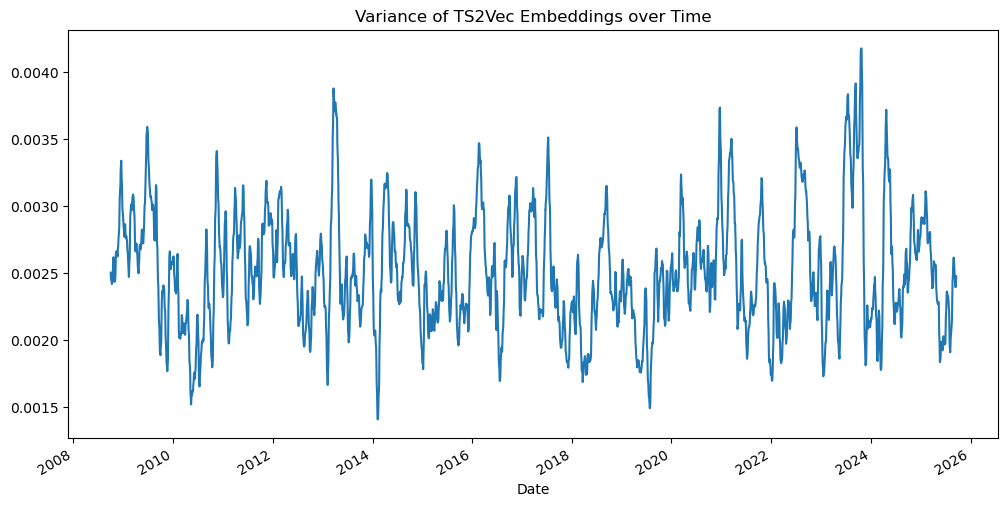

In [94]:
# variance of each sample
val_df.var(axis=1).plot(figsize=(12, 6), title='Variance of TS2Vec Embeddings over Time')

In [70]:
kmeans = KMeans(n_clusters=5, random_state=0)
labels = kmeans.fit_predict(embeddings_full)

In [71]:
hmm = GaussianHMM(n_components=5, covariance_type="full", n_iter=2000).fit(embeddings_full)
labels = hmm.predict(embeddings_full)

In [75]:
# hdbscan clustering
clusterer = HDBSCAN(min_cluster_size=30, cluster_selection_method="leaf")
labels = clusterer.fit_predict(embeddings_full)

In [86]:
# GaussianMixture
gmm = GaussianMixture(n_components=3, covariance_type="full", max_iter=2000).fit(embeddings_full)
labels = gmm.predict(embeddings_full)

In [97]:
# probability of each cluster
probs = gmm.predict_proba(embeddings_full)
probs_df = pd.DataFrame(
    probs,
    index=data.index[window_size - 1 : window_size - 1 + len(embeddings_full)],
    columns=[f'Cluster_{i}_Prob' for i in range(probs.shape[1])]
)
probs_df

,Cluster_0_Prob,Cluster_1_Prob,Cluster_2_Prob
Date,,,
2008-03-07 00:00:00+05:30,0.0,1.0,0.0
2008-03-10 00:00:00+05:30,0.0,1.0,0.0
2008-03-11 00:00:00+05:30,0.0,1.0,0.0
2008-03-12 00:00:00+05:30,0.0,1.0,0.0
2008-03-13 00:00:00+05:30,0.0,1.0,0.0
...,...,...,...
2025-09-12 00:00:00+05:30,1.0,0.0,0.0
2025-09-15 00:00:00+05:30,1.0,0.0,0.0
2025-09-16 00:00:00+05:30,1.0,0.0,0.0


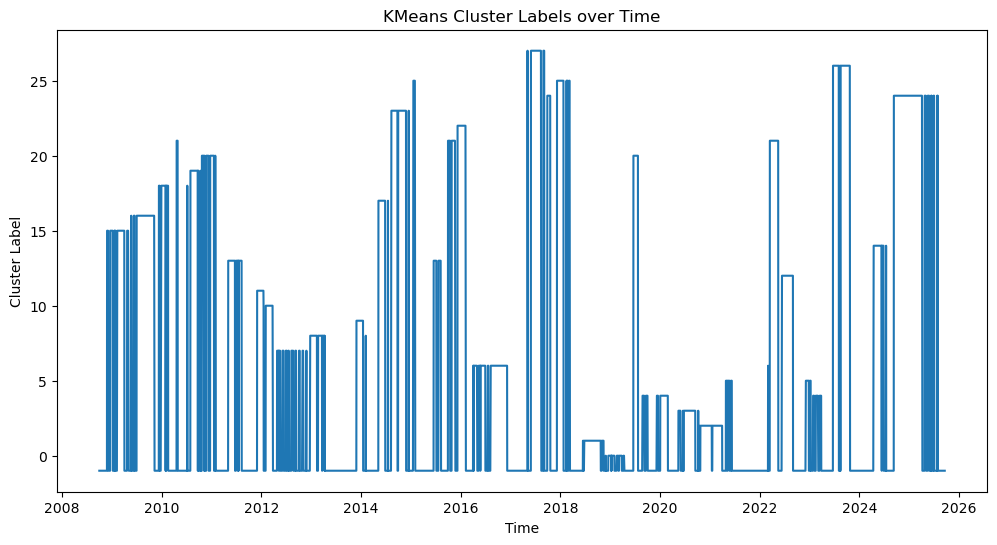

In [73]:
# plot the cluster labels over time
plt.figure(figsize=(12, 6))
plt.plot(val_df.index, labels)
plt.title('KMeans Cluster Labels over Time')
plt.xlabel('Time')
plt.ylabel('Cluster Label')
plt.show()

In [77]:
val_df["Close"] = close.iloc[window_size - 1 : window_size - 1 + len(embeddings_full)].values
val_df["Cluster"] = labels

In [78]:
# nifty_obj = yf.Ticker('^NSEI')
# nifty_data = nifty_obj.history(start=val_df.index[0], end=val_df.index[-1])

In [79]:
# nifty_data

In [80]:
# # merge cluster labels with nifty close prices
# nifty_merge = nifty_data.merge(
#     pd.DataFrame({'Cluster': labels}, index=val_df.index),
#     left_index=True,
#     right_index=True,
#     how='left'
# )

In [81]:
# nifty_merge

In [82]:
np.unique(labels, return_counts=True)

(array([-1,  0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15,
        16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27]),
 array([2271,   57,   92,  109,   72,   89,   40,  134,   53,   65,   33,
          36,   30,   56,   89,   49,   62,   92,   37,   36,   40,   69,
          74,   40,   66,  180,   52,   77,   59]))

In [83]:
colors = {0:"green", 1:"red", 2:"blue", 3:"orange", 4:"purple", 5:"brown", 6:"pink", 7:"gray", 8:"cyan", 9:"magenta", -1:"black"}
# for 20 clusters
colors = {i:plt.cm.tab20(i) for i in range(20)}

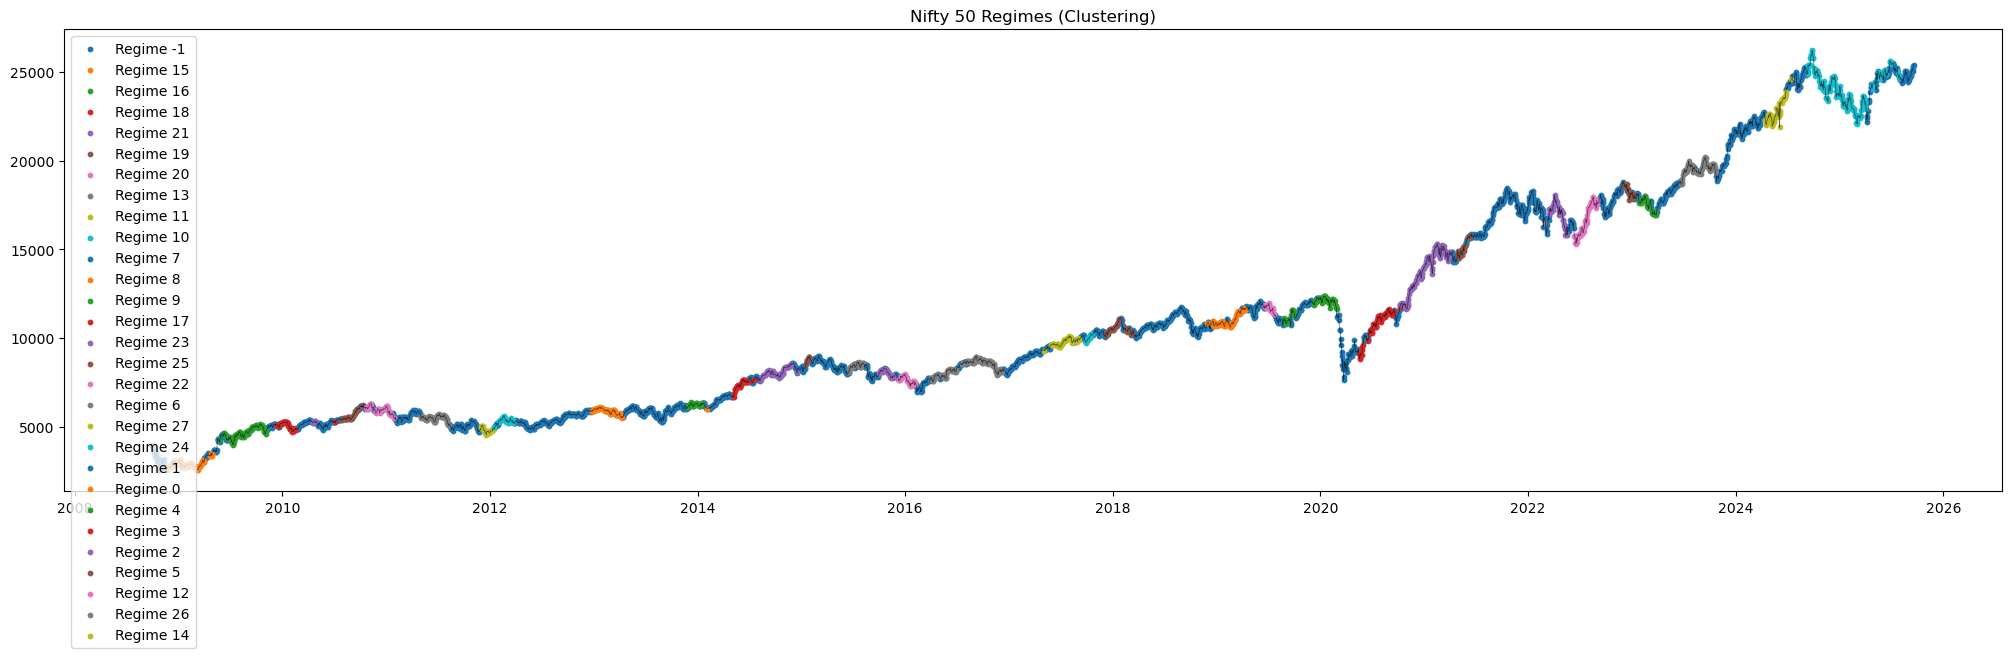

In [84]:
plt.figure(figsize=(25,6))
for c in val_df['Cluster'].dropna().unique():
    mask = val_df['Cluster'] == c
    plt.scatter(val_df.index[mask], val_df['Close'][mask], label=f"Regime {c}", s=10)
plt.plot(val_df.index, val_df['Close'], color='black', linewidth=0.5, alpha=0.6)
plt.title("Nifty 50 Regimes (Clustering)")
plt.legend()
plt.show()

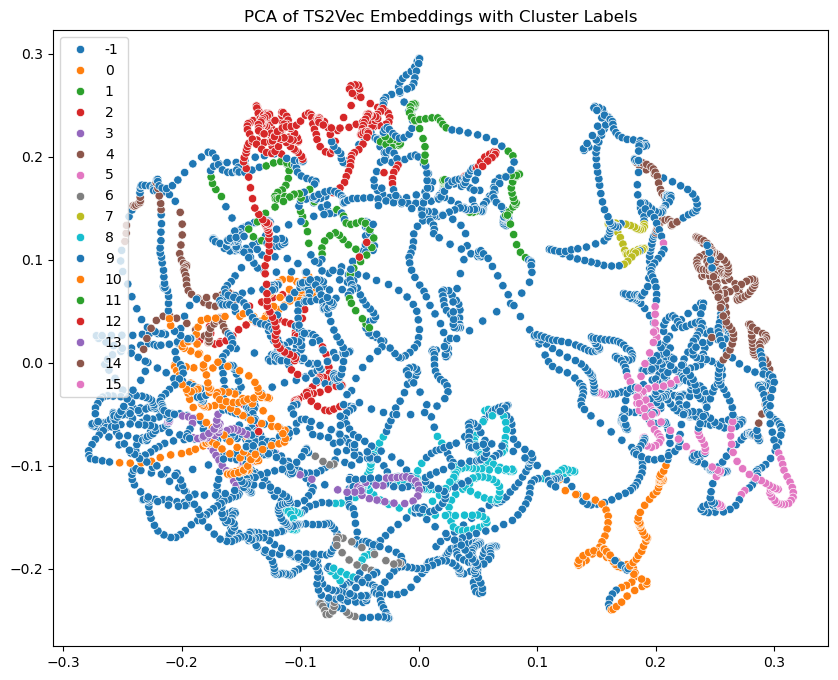

In [81]:
# implement PCA for visualization
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
embeddings_2d = pca.fit_transform(embeddings_full)
plt.figure(figsize=(10, 8))
sns.scatterplot(x=embeddings_2d[:, 0], y=embeddings_2d[:, 1], hue=labels, palette="tab10", legend="full")
plt.title("PCA of TS2Vec Embeddings with Cluster Labels")
plt.show()

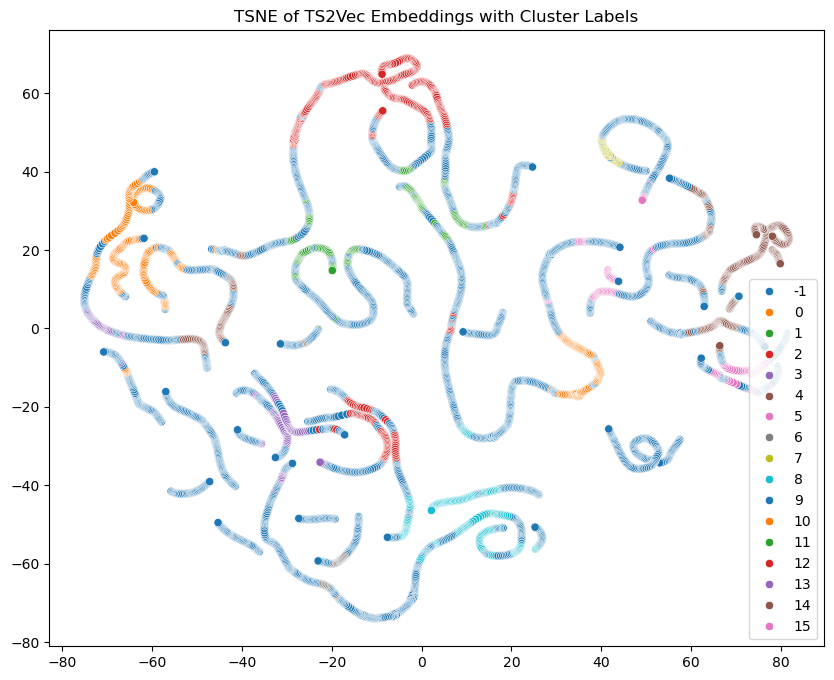

In [82]:
# import TSNE
from sklearn.manifold import TSNE
tsne = TSNE(n_components=2, random_state=0)
embeddings_tsne = tsne.fit_transform(embeddings_full)
plt.figure(figsize=(10, 8))
sns.scatterplot(x=embeddings_tsne[:, 0], y=embeddings_tsne[:, 1], hue=labels, palette="tab10", legend="full")
plt.title("TSNE of TS2Vec Embeddings with Cluster Labels")
plt.show()

/opt/miniconda3/lib/python3.12/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


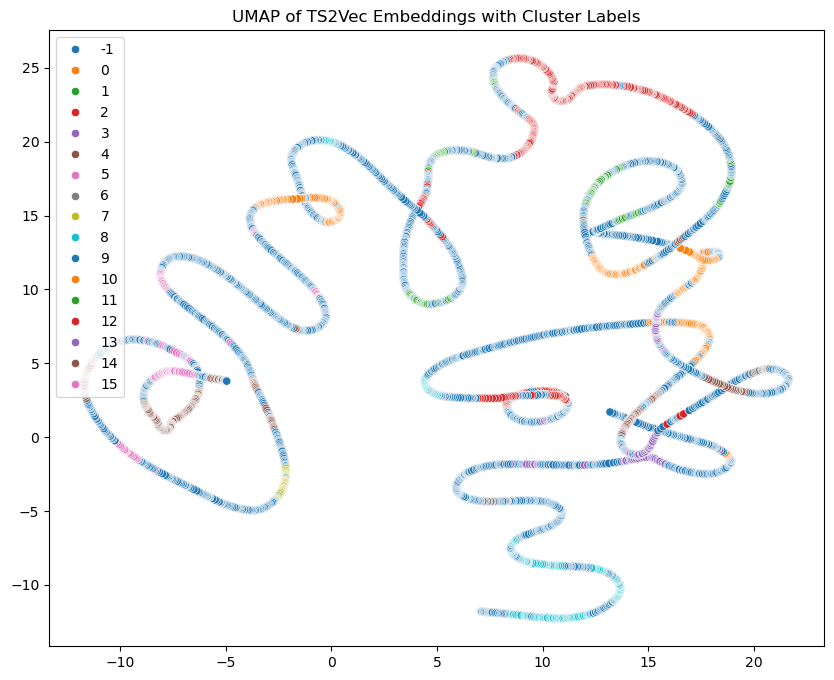

In [84]:
# implement umap for visualization
import umap
reducer = umap.UMAP( n_jobs=-1)
embeddings_umap = reducer.fit_transform(embeddings_full)
plt.figure(figsize=(10, 8))
sns.scatterplot(x=embeddings_umap[:, 0], y=embeddings_umap[:, 1], hue=labels, palette="tab10", legend="full")
plt.title("UMAP of TS2Vec Embeddings with Cluster Labels")
plt.show()